In [1]:
# 1. Data Import and Initial Inspection
import pandas as pd

# Load the raw e-commerce dataset
df = pd.read_csv('data.csv')

# Display the first few rows to understand the data structure
display(df.head())

# Check data types and overall dataset information
df.info()

# Identify the number of missing values in each column
print(df.isnull().sum())

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


<class 'pandas.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  str    
 1   Customer ID       12575 non-null  str    
 2   Category          12575 non-null  str    
 3   Item              11362 non-null  str    
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  str    
 8   Location          12575 non-null  str    
 9   Transaction Date  12575 non-null  str    
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(1), str(7)
memory usage: 1.9+ MB
Transaction ID         0
Customer ID            0
Category               0
Item                1213
Price Per Unit       609
Quantity             604
Total Spent          604
Payment Method         0
Location               0
Transa

In [2]:
# 2. Data Cleaning Process

# Handle missing values in the 'Discount Applied' column. 
# We assume that a missing value indicates no discount was applied (False).
df['Discount Applied'] = df['Discount Applied'].fillna(False)

# Drop remaining rows with missing critical information (e.g., Price, Quantity, Item).
df_clean = df.dropna()

# Create a clean copy and convert the 'Transaction Date' column to datetime format
df_clean = df_clean.copy() 
df_clean['Transaction Date'] = pd.to_datetime(df_clean['Transaction Date'])

# Verify the cleaning process
print("Remaining rows after cleaning:", len(df_clean))
print("-" * 30)
print(df_clean.isnull().sum()) # Should all be 0 now

Remaining rows after cleaning: 11362
------------------------------
Transaction ID      0
Customer ID         0
Category            0
Item                0
Price Per Unit      0
Quantity            0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
Discount Applied    0
dtype: int64


In [3]:
# 3. Data Export
# Save the cleaned dataset to a new CSV file for the Exploratory Data Analysis (EDA) phase
df_clean.to_csv('cleaned_data.csv', index=False)
print("File saved successfully as 'cleaned_data.csv'!")

File saved successfully as 'cleaned_data.csv'!


In [4]:
# 4. Exploratory Data Analysis (EDA) Setup

# Import visualization libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional theme for the plots
sns.set_theme(style="whitegrid")

# Load the cleaned dataplt.show()
df = pd.read_csv('cleaned_data.csv')

# Re-convert the date column to datetime (since CSV saves it as a string)
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])

print("Setup complete. Ready for visual analysis!")

Setup complete. Ready for visual analysis!


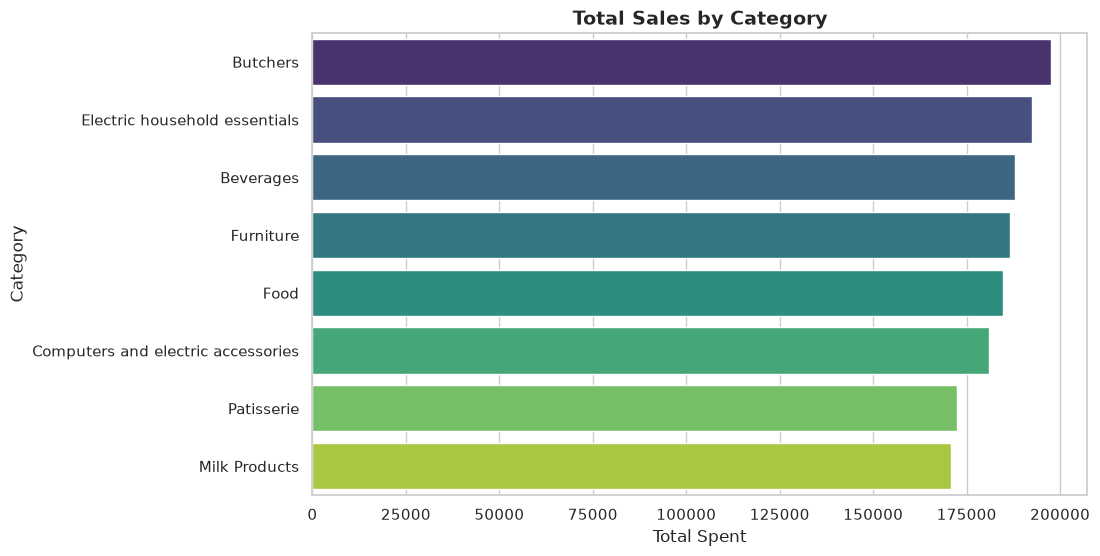

In [5]:
# 5. Visualizing Total Sales by Category
plt.figure(figsize=(10, 6))

# Group data by category and calculate total sales, sorted in descending order
category_sales = df.groupby('Category')['Total Spent'].sum().sort_values(ascending=False)

# Create a bar plot using modern Seaborn syntax
sns.barplot(x=category_sales.values, y=category_sales.index, hue=category_sales.index, palette='viridis', legend=False)

# Add labels and title
plt.title('Total Sales by Category', fontsize=14, fontweight='bold')
plt.xlabel('Total Spent')
plt.ylabel('Category')

plt.show()

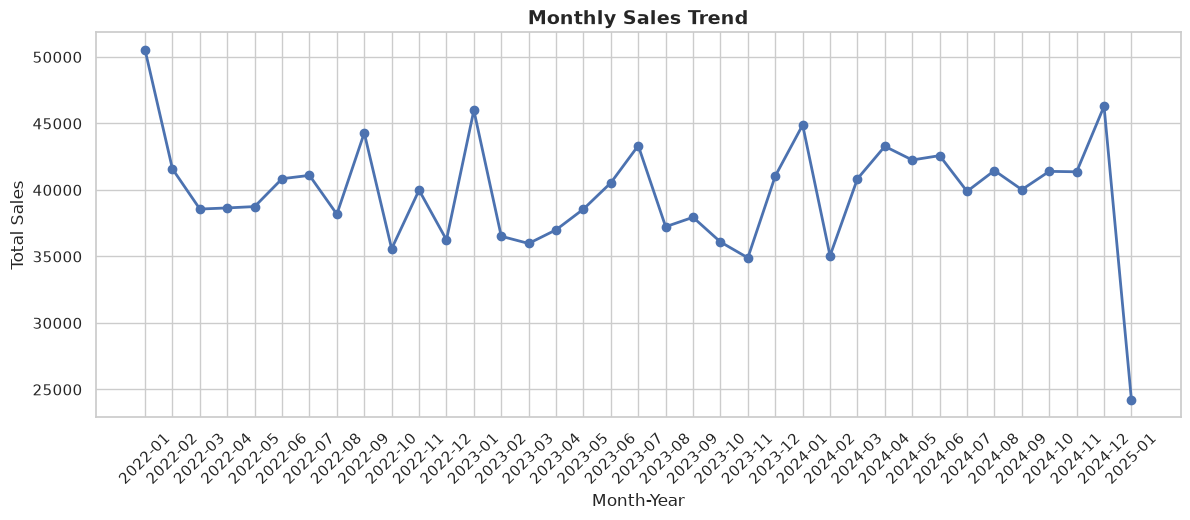

In [6]:
# 6. Visualizing Monthly Sales Trend
plt.figure(figsize=(14, 5))

# Create a new column containing only the Year and Month (e.g., 2023-07)
df['Month_Year'] = df['Transaction Date'].dt.to_period('M').astype(str)

# Group sales by the new Month_Year column
monthly_sales = df.groupby('Month_Year')['Total Spent'].sum()

# Create a line plot to observe trends over time
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', color='b', linewidth=2)

# Add labels and title
plt.title('Monthly Sales Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month-Year')
plt.ylabel('Total Sales')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)
plt.show()

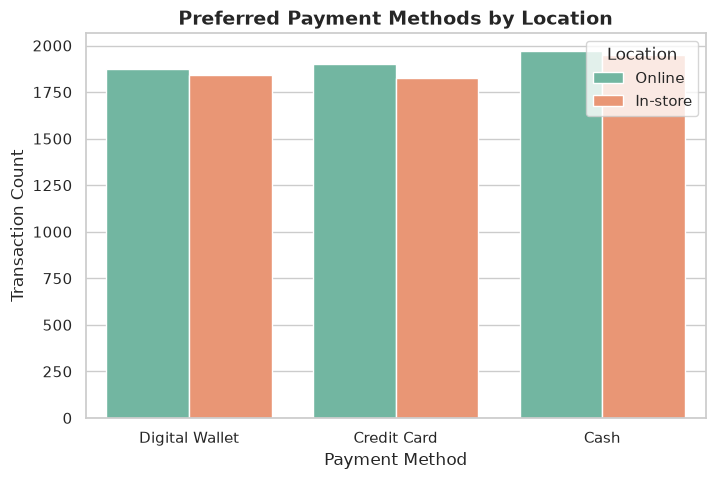

In [7]:
# 7. Visualizing Preferred Payment Methods by Location
plt.figure(figsize=(8, 5))

# Create a count plot to see transaction counts for each payment method, split by location
sns.countplot(data=df, x='Payment Method', hue='Location', palette='Set2')

# Add labels and title
plt.title('Preferred Payment Methods by Location', fontsize=14, fontweight='bold')
plt.xlabel('Payment Method')
plt.ylabel('Transaction Count')

plt.show()